# Computational Text Analysis Workshop

This notebook walks through four core techniques in computational text analysis:

1. **Loading and tokenization**: turning raw text into units a computer can count
2. **Embeddings**: representing meaning as numbers, and measuring semantic similarity
3. **Sentiment analysis**: scoring text for positive and negative tone
4. **Topic modeling**: discovering what groups of documents are "about"

**No coding experience is needed.** You will not have to write code from scratch. Some cells have form fields on the right side (text boxes, dropdowns, sliders) where you can type your own words or change settings.

### How to use this notebook
- A **cell** is one box. Gray boxes are code; white boxes (like this one) are explanations.
- To **run** a code cell, click it and press **Shift + Enter**, or click the ▶ button on its left.
- **Run the cells in order, from top to bottom.** Later cells depend on earlier ones.
- If you see a warning in red/orange text, it is usually harmless. If you see an actual error, try **Runtime → Restart session and run all**.
- *Optional speed-up:* **Runtime → Change runtime type → T4 GPU** makes the embedding steps faster. Everything also works without it.

---
# Part 0: Setup

This cell installs two tools that are not built into Colab and loads everything else we need. It takes about a minute the first time. You only need to run it once per session.

In [1]:
!pip install -q sentence-transformers umap-learn

import re, textwrap, warnings
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

import umap
from sentence_transformers import SentenceTransformer

# Small data files that NLTK needs (word lists, tokenizer rules, sentiment lexicon)
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

Setup complete ✔


---
# Part 1: Loading, Viewing, and Tokenizing Text

## 1.1 Load a dataset

We will use the **20 Newsgroups** dataset, which comes built into the `scikit-learn` library. It contains posts from Usenet discussion forums ("newsgroups") from the early 1990s — essentially an early version of Reddit.

To keep things fast, we take **3 of the 20 forums** and **150 posts from each** (450 posts total). We also strip out email headers, signatures, and quoted replies so we are left with just what each person wrote.

The result is a **table** (called a *DataFrame*) with one row per post and two columns:
- `text`: the post itself
- `group`: which forum it came from

In [4]:
forums = {
    "rec.sport.hockey":       "hockey",
    "sci.space":              "space",
    "sci.med":                "medicine"
}

raw = fetch_20newsgroups(subset="train", categories=list(forums),
                         remove=("headers", "footers", "quotes"), random_state=42)

df = pd.DataFrame({
    "text":  raw.data,
    "group": [forums[raw.target_names[i]] for i in raw.target],
})

df["text"] = df["text"].str.replace(r"\s+", " ", regex=True).str.strip() # collapse extra spaces and line breaks
df = df[df["text"].str.len() > 100] # drop very short posts
df = df.groupby("group", group_keys=False).sample(n=150, random_state=42).reset_index(drop=True) # keep 150 posts/forum
df["text"] = df["text"].str[:2000] # cap long posts at 2000 characters

print(f"Loaded {len(df)} posts.")

Loaded 450 posts.


## 1.2 View the data

First, the top 5 rows of the table:

In [7]:
df.sample(n=5)

,text,group
313,Did the Russian spacecraft(s) on the ill-fated Phobos mission a few years ago send back any images of the Martian mo...,space
130,"Here are the results after three days of voting. Remember 3pts for 1st, 2 for 2nd, and 1 for 3rd. Also, you can stil...",hockey
442,"I've seen a film of it, my memory may be faulty, but as I remember it the vehicle was slightly over a meter long, wi...",space
217,"I noticed several years ago that when I took analgesics fairly regularly, (motrin at the time), I seemed to get a lo...",medicine
201,"Gee! Maybe I've misjudged you, Russell. Anyone who agrees with something I say can't be all bad. ;-) Seriously, I'm ...",medicine


How many posts come from each forum?

In [8]:
df["group"].value_counts()

,count
group,
hockey,150
medicine,150
space,150


Now read one full post. Change the row number (0 to 449) in the box on the right and re-run the cell to read a different one.

In [13]:
#@title Read a single post
row = 15 #@param {type:"integer"}

print("Forum:", df.loc[row, "group"])
print(textwrap.fill(df.loc[row, "text"], 100))

Forum: hockey
Don't you Americans study history...the French settled in North America as early or before the
British...Lemieux can probably trace back his North American heritage back a lot further than most
of us.


## 1.3 Processing text, one step at a time

A computer does not see "words." It sees a long string of characters. Before we can count anything, we have to decide **what counts as a word** and **which words matter**. Every one of these decisions is a linguistic choice, and each one throws information away.

We will walk through the standard pipeline on one sentence first:

In [16]:
#@title The example sentence
example = "The Rangers weren't playing well tonight, but I still think they'll win the Cup in 1994!!" #@param {type:"string"}
print(example)

The Rangers weren't playing well tonight, but I still think they'll win the Cup in 1994!!


### Step 1: Lowercase
So that *The* and *the* count as the same word. (Cost: we lose the difference between *Apple* the company and *apple* the fruit.)

In [17]:
step1 = example.lower()
print(step1)

the rangers weren't playing well tonight, but i still think they'll win the cup in 1994!!


### Step 2: Tokenize (split into words)
The simplest approach is to split wherever there is a space. Notice the problem: punctuation stays glued to words (`tonight,` and `1994!!`), so `tonight,` and `tonight` would be counted as different words.

In [18]:
naive_tokens = step1.split()
print(naive_tokens)

['the', 'rangers', "weren't", 'playing', 'well', 'tonight,', 'but', 'i', 'still', 'think', "they'll", 'win', 'the', 'cup', 'in', '1994!!']


A proper **tokenizer** uses rules to separate punctuation. Look at what it does with contractions: *weren't* becomes `were` + `n't`, and *they'll* becomes `they` + `'ll`. The tokenizer is making a morphological analysis.

In [19]:
step2 = word_tokenize(step1)
print(step2)

['the', 'rangers', 'were', "n't", 'playing', 'well', 'tonight', ',', 'but', 'i', 'still', 'think', 'they', "'ll", 'win', 'the', 'cup', 'in', '1994', '!', '!']


### Step 3: Keep only alphabetic tokens
Remove punctuation and numbers. Watch what else disappears: `n't` is not purely alphabetic, so **the negation is gone**.

In [20]:
step3 = [tok for tok in step2 if tok.isalpha()]
print(step3)
print("\nRemoved:", [tok for tok in step2 if not tok.isalpha()])

['the', 'rangers', 'were', 'playing', 'well', 'tonight', 'but', 'i', 'still', 'think', 'they', 'win', 'the', 'cup', 'in']

Removed: ["n't", ',', "'ll", '1994', '!', '!']


### Step 4: Remove stopwords
**Stopwords** are very frequent function words (*the, and, of, I, was*) that appear in almost every text. For counting what a text is *about*, they are mostly noise. Here is the standard English list from NLTK:

In [22]:
STOPWORDS = set(stopwords.words("english"))
print(f"{len(STOPWORDS)} stopwords. The first 10 alphabetically:\n")
print(sorted(STOPWORDS)[:10])

198 stopwords. The first 10 alphabetically:

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']


In [23]:
step4 = [tok for tok in step3 if tok not in STOPWORDS]
print(step4)
print("\nRemoved:", [tok for tok in step3 if tok in STOPWORDS])

['rangers', 'playing', 'well', 'tonight', 'still', 'think', 'win', 'cup']

Removed: ['the', 'were', 'but', 'i', 'they', 'the', 'in']


Note that the result of tokenization creates a sentence (or a list of words approximating a sentence) with a meaning opposite to the original sentence.

**This is the key lesson of Part 1:** cleaning is fine for questions like *"what is this text about?"* but destructive for questions like *"what is this text saying?"* That is why, later in this notebook, sentiment analysis and embeddings are run on the **raw** text, not the cleaned text.

### Step 5: Lemmatize
**Lemmatization** reduces inflected forms to a dictionary headword (*cups → cup*, *geese → goose*). The lemmatizer needs to know the part of speech, and without it, it assumes everything is a noun, which produces some odd results:

In [24]:
lemmatizer = WordNetLemmatizer()

demo_words = ["cups", "geese", "playing", "ran", "better", "was", "has"]
pd.DataFrame({
    "word":             demo_words,
    "as noun (default)": [lemmatizer.lemmatize(w, pos="n") for w in demo_words],
    "as verb":          [lemmatizer.lemmatize(w, pos="v") for w in demo_words],
    "as adjective":     [lemmatizer.lemmatize(w, pos="a") for w in demo_words],
})

,word,as noun (default),as verb,as adjective
0,cups,cup,cup,cups
1,geese,goose,geese,geese
2,playing,playing,play,playing
3,ran,ran,run,ran
4,better,better,better,good
5,was,wa,be,was
6,has,ha,have,has


### Putting it together

Below, all the steps are bundled into one function called `clean_text`. We also drop tokens shorter than 3 letters, and you can add your own **custom stopwords**, words that are common in this particular dataset but uninformative (e.g., *would, like, know*).

In [26]:
#@title Build the cleaning function (and add custom stopwords)
extra_stopwords = "would, could, also, one, get, like, know, think, say, use, much, even, well, may, might, us, want, make, see, thing, anyone, something, really" #@param {type:"string"}

STOPWORDS = set(stopwords.words("english")) | {w.strip().lower() for w in extra_stopwords.split(",") if w.strip()}

def clean_text(text):
    tokens = word_tokenize(text.lower())                 # steps 1–2: lowercase + tokenize
    tokens = [t for t in tokens if t.isalpha()]          # step 3: letters only
    tokens = [t for t in tokens if t not in STOPWORDS]   # step 4: remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # step 5: lemmatize
    tokens = [t for t in tokens if len(t) > 2]           # drop very short leftovers
    return tokens

print("Stopword list now has", len(STOPWORDS), "words.")

Stopword list now has 221 words.


In [28]:
#@title Try it on your own sentence
my_sentence = "I absolutely didn't enjoy the chapter on phonology, but the section about syntax was great." #@param {type:"string"}
print("Original:", my_sentence)
print("Cleaned: ", clean_text(my_sentence))

Original: I absolutely didn't enjoy the chapter on phonology, but the section about syntax was great.
Cleaned:  ['absolutely', 'enjoy', 'chapter', 'phonology', 'section', 'syntax', 'great']


### Apply the cleaning to all 450 posts
We store the result in two new columns: `tokens` (a list of words) and `clean_text` (the same words joined back into a string).

In [29]:
df["tokens"] = df["text"].apply(clean_text)
df["clean_text"] = df["tokens"].apply(" ".join)

row = 7
print("BEFORE:\n", textwrap.fill(df.loc[row, "text"][:400], 100))
print("\nAFTER:\n", textwrap.fill(df.loc[row, "clean_text"][:400], 100))

BEFORE:
 Are you comparing Cullen to Salami? I would say that that is valid. If Winnipeg is such a lousy
defensive team then why the hell does Salami stand around the other team's blueline when the puck is
in his own end? Excuse me? Are the Jets playing .500 hockey? Let me check...yes - but just barely.
They have allowed more goals than they have scored. Sounds an awful lot like Salami's +/- to me.
Sounds

AFTER:
 comparing cullen salami valid winnipeg lousy defensive team hell salami stand around team blueline
puck end excuse jet playing hockey let check yes barely allowed goal scored sound awful lot salami
sound better played solid game friend finland claim capable lenging league lead goal challenging
first however let compared timo anderson cullen next mike foligno finnish friend watched play claim
play


### What difference does cleaning make? Word frequencies before vs. after

On the left, the 20 most frequent tokens with only lowercasing and tokenization. On the right, the 20 most frequent after the full cleaning pipeline.

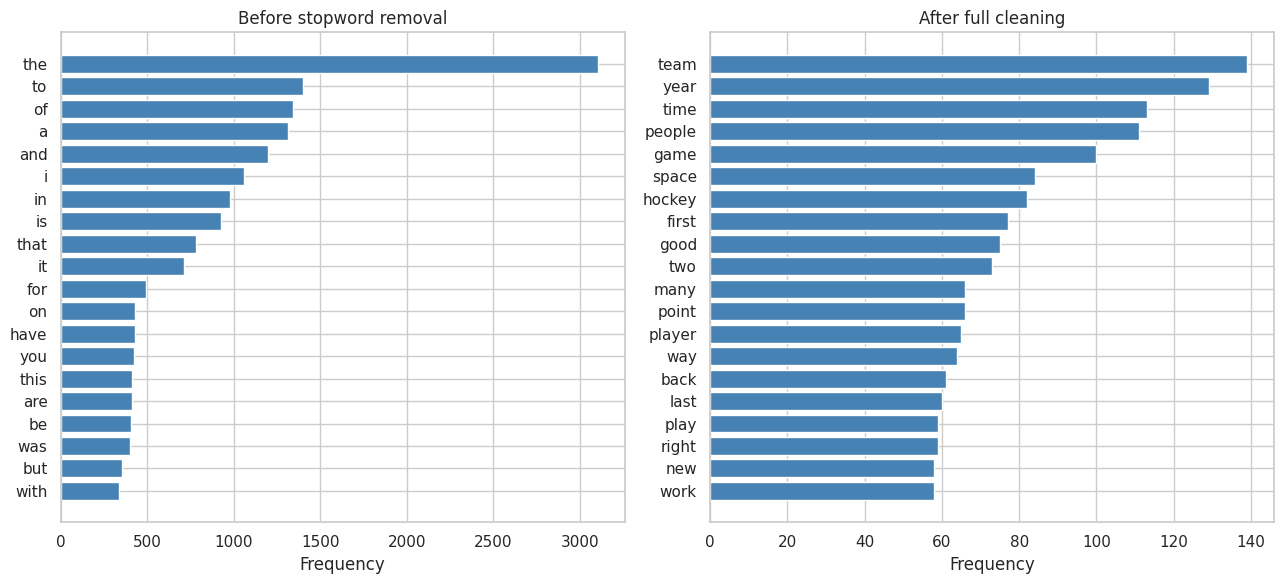

Total tokens before: 55,935   after: 27,269
Unique word types before: 8,347   after: 7,258


In [30]:
raw_counts   = Counter(t for text in df["text"] for t in word_tokenize(text.lower()) if t.isalpha())
clean_counts = Counter(t for toks in df["tokens"] for t in toks)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, counts, title in [(axes[0], raw_counts, "Before stopword removal"),
                          (axes[1], clean_counts, "After full cleaning")]:
    words, freqs = zip(*counts.most_common(20))
    ax.barh(words[::-1], freqs[::-1], color="steelblue")
    ax.set_title(title); ax.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

print(f"Total tokens before: {sum(raw_counts.values()):,}   after: {sum(clean_counts.values()):,}")
print(f"Unique word types before: {len(raw_counts):,}   after: {len(clean_counts):,}")

Once function words are gone, **content words** become visible. Let's look at the most frequent words within each forum. Even simple counts already reveal what each forum is about.

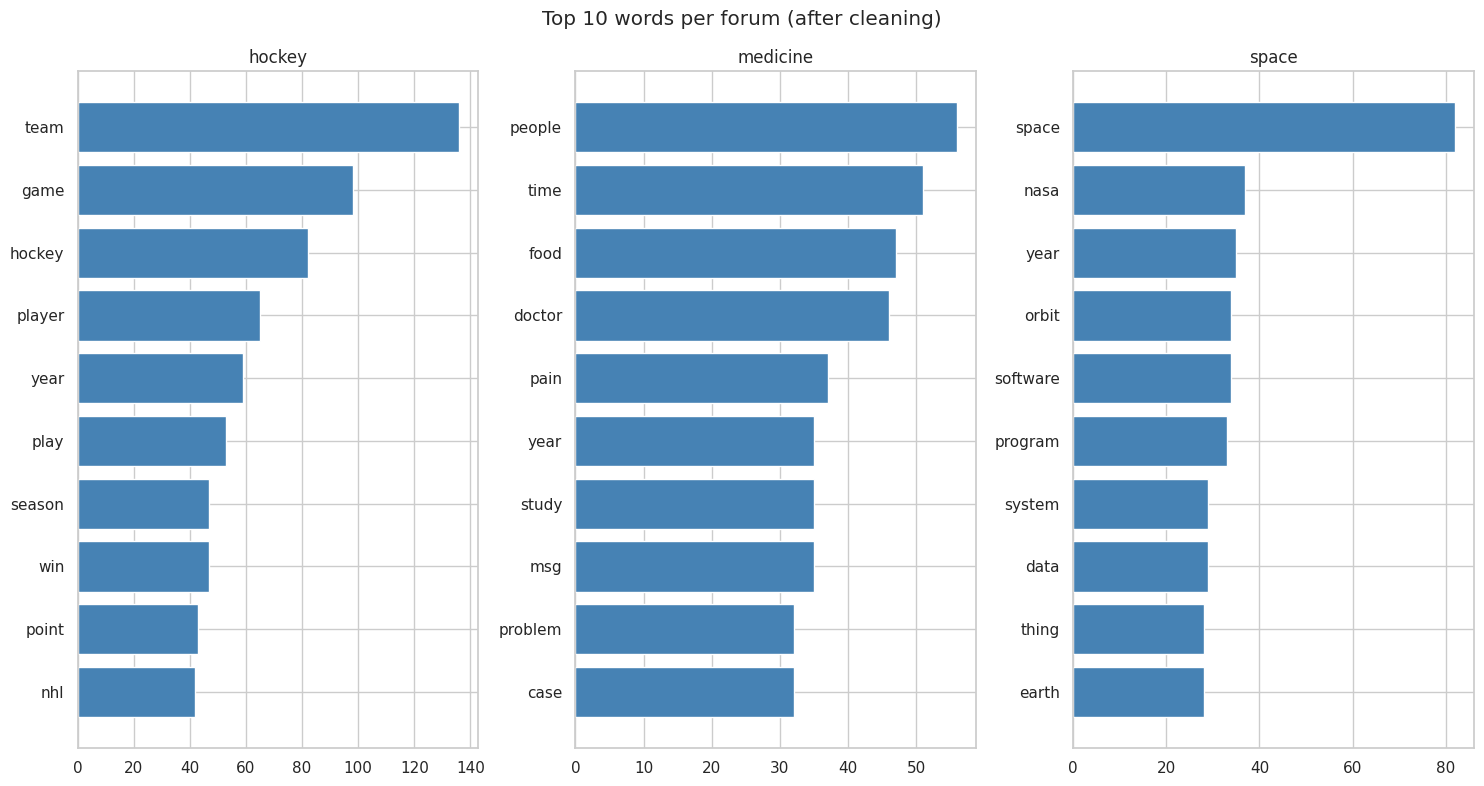

In [35]:
groups = sorted(df["group"].unique())
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
for ax, g in zip(axes.flat, groups):
    counts = Counter(t for toks in df.loc[df["group"] == g, "tokens"] for t in toks)
    words, freqs = zip(*counts.most_common(10))
    ax.barh(words[::-1], freqs[::-1], color="steelblue")
    ax.set_title(g)
plt.suptitle("Top 10 words per forum (after cleaning)")
plt.tight_layout(); plt.show()

---
# Part 2: Embeddings: Meaning as Numbers

Counting words treats *pizza* and *cheese* as completely unrelated symbols, exactly as unrelated as *pizza* and *telescope*. **Embeddings** fix this by representing each word or sentence as a list of numbers (a **vector**) such that texts with similar meanings get similar numbers.

The idea comes from the **distributional hypothesis** in linguistics — J.R. Firth's "you shall know a word by the company it keeps." A neural network reads huge amounts of text and learns to place words used in similar contexts near each other.

We use a small, fast model called **all-MiniLM-L6-v2**. It turns any word, phrase, or sentence into **384 numbers**. (The first run downloads the model, about 90 MB.)

In [36]:
#@title Load the embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("cheese")
print("The embedding for 'cheese' is a list of", len(vec), "numbers.")
print("Here are the first 10:\n", np.round(vec[:10], 3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

The embedding for 'cheese' is a list of 384 numbers.
Here are the first 10:
 [-0.051 -0.005 -0.026  0.078 -0.071  0.002  0.088  0.059 -0.003 -0.063]


Those numbers mean nothing individually. What matters is how two vectors **compare**. We measure this with **cosine similarity**, which ranges roughly from 0 (unrelated) to 1 (identical meaning). It can technically go negative, but for this model that is rare.

## 2.1 Compare your own words and phrases

Type any two words, phrases, or sentences on the right and run the cell.

In [40]:
#@title Compare two words or phrases
phrase_1 = "cheese" #@param {type:"string"}
phrase_2 = "pizza" #@param {type:"string"}

def similarity(a, b):
    ea, eb = model.encode([a, b])
    return float(cosine_similarity([ea], [eb])[0, 0])

print(f"Similarity between '{phrase_1}' and '{phrase_2}': {similarity(phrase_1, phrase_2):.3f}")

Similarity between 'cheese' and 'pizza': 0.623


In [42]:
pairs = [("cheese", "pizza"), ("pineapple", "pizza"), ("pineapple", "mango"),
         ("pizza", "telescope"), ("happy", "glad"), ("happy", "sad"),
         ("dog", "puppy"), ("dog", "democracy")]

pd.DataFrame([{"word A": a, "word B": b, "similarity": round(similarity(a, b), 3)} for a, b in pairs]) \
  .sort_values("similarity", ascending=False).reset_index(drop=True)

,word A,word B,similarity
0,dog,puppy,0.804
1,cheese,pizza,0.623
2,happy,glad,0.570
3,pineapple,pizza,0.561
4,pineapple,mango,0.481
5,happy,sad,0.373
6,pizza,telescope,0.274
7,dog,democracy,0.272


### A similarity grid for your own word list

Enter a comma-separated list. Every word is compared with every other word; darker squares mean more similar.

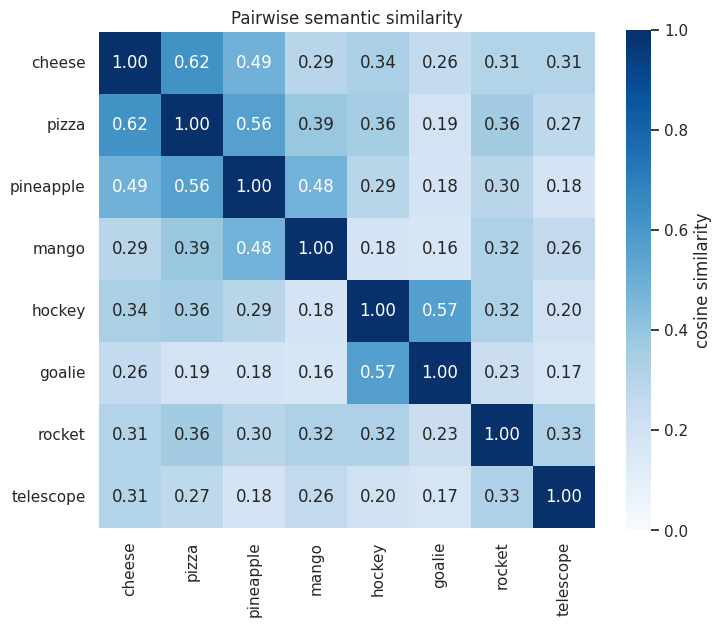

In [44]:
#@title Similarity heatmap
word_list = "cheese, pizza, pineapple, mango, hockey, goalie, rocket, telescope" #@param {type:"string"}

words = [w.strip() for w in word_list.split(",") if w.strip()]
word_vecs = model.encode(words)
sim_matrix = cosine_similarity(word_vecs)

plt.figure(figsize=(8, 6.5))
sns.heatmap(pd.DataFrame(sim_matrix, index=words, columns=words), annot=True, fmt=".2f",
            cmap="Blues", vmin=0, vmax=1, square=True, cbar_kws={"label": "cosine similarity"})
plt.title("Pairwise semantic similarity"); plt.show()

### Seeing the space

We cannot picture 384 dimensions, so we squash them down to 2 using **PCA** (principal component analysis). Some information is lost, but related words should still land near each other.

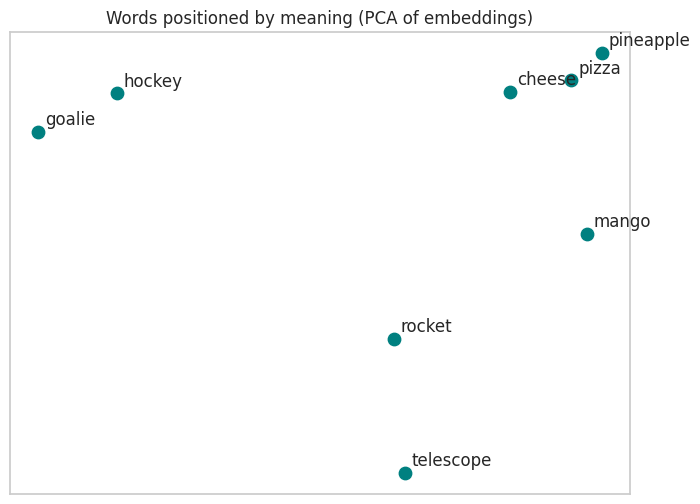

In [45]:
#@title Plot the word list in 2D
coords_2d = PCA(n_components=2, random_state=42).fit_transform(word_vecs)

plt.figure(figsize=(8, 6))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], s=80, color="teal")
for (x, y), w in zip(coords_2d, words):
    plt.annotate(w, (x, y), xytext=(5, 5), textcoords="offset points", fontsize=12)
plt.title("Words positioned by meaning (PCA of embeddings)")
plt.xticks([]); plt.yticks([]); plt.show()

### Context matters: polysemy

This model embeds whole sentences, and it reads words **in context**. The same word, *bank*, in different senses:

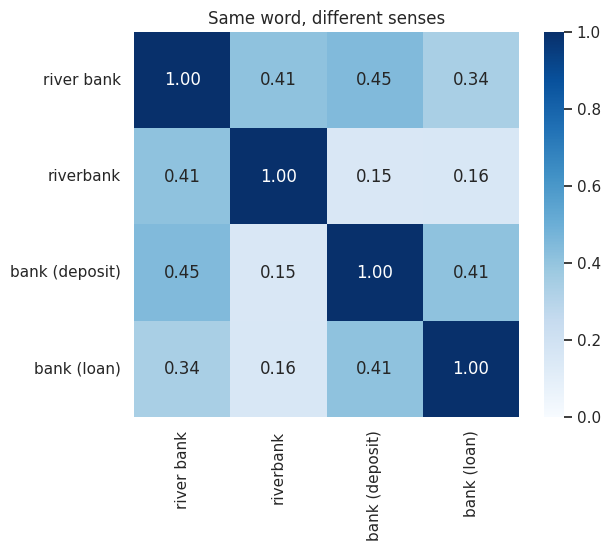

In [46]:
bank_sentences = [
    "I sat on the bank of the river.",
    "The muddy riverbank was covered in reeds.",
    "I deposited my paycheck at the bank.",
    "The bank approved my loan application.",
]
bank_vecs = model.encode(bank_sentences)
short = ["river bank", "riverbank", "bank (deposit)", "bank (loan)"]

plt.figure(figsize=(6.5, 5))
sns.heatmap(pd.DataFrame(cosine_similarity(bank_vecs), index=short, columns=short),
            annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True)
plt.title("Same word, different senses"); plt.show()

## 2.2 Embedding the whole dataset

Now we give every one of the posts its own 384-number vector. Note that we feed in the **raw text**, not the cleaned version: this model was trained on natural sentences and uses word order, function words, and negation.

(The model only reads roughly the first 200 words of each post; the rest is ignored. This takes about 30–90 seconds on a regular CPU and a few seconds on a GPU.)

In [47]:
#@title Embed all posts
embeddings = model.encode(df["text"].tolist(), batch_size=32, show_progress_bar=True)
print("Embedding table shape:", embeddings.shape, "= (posts, numbers per post)")

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Embedding table shape: (450, 384) → (posts, numbers per post)


### Visualize with UMAP

**UMAP** is another way to squash high-dimensional data into 2D. Unlike PCA, it focuses on preserving **neighborhoods**: posts that are close in the 384-dimensional space should stay close on the map.

Each dot is one post, colored by the forum it came from. **Hover over a dot to read the post.** You can also click forum names in the legend to hide or show them.

Important: the embedding model was **never told** which forum each post came from. If the colors form clusters, the model found that structure purely from meaning.

In [48]:
#@title Map of all posts (UMAP)
umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
coords = umap_2d.fit_transform(embeddings)
df["x"], df["y"] = coords[:, 0], coords[:, 1]

# A wrapped preview of each post for the hover box
df["preview"] = df["text"].apply(lambda t: "<br>".join(textwrap.wrap(t[:250], 60)) + "...")

fig = px.scatter(df, x="x", y="y", color="group", hover_data={"preview": True, "x": False, "y": False},
                 title="Forum posts positioned by meaning (UMAP of embeddings)", height=600)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_xaxes(showticklabels=False, title=""); fig.update_yaxes(showticklabels=False, title="")
fig.show()

### Bonus: semantic search

Because every post has a vector, we can embed a **query** and find the posts closest in meaning, even if they share **no words** with the query. Try your own.

In [49]:
#@title Search posts by meaning
query = "who is the best goalie in the league?" #@param {type:"string"}
n_results = 5 #@param {type:"integer"}

sims = cosine_similarity(model.encode([query]), embeddings)[0]
for i in np.argsort(sims)[::-1][:n_results]:
    print(f"similarity {sims[i]:.3f} | {df['group'].iloc[i]}")
    print(textwrap.fill(df["text"].iloc[i][:300], 100), "...\n")

similarity 0.539 | hockey
: > : >ATLANTIC DIVISION : > : > ST JOHN'S MAPLE LEAFS VS MONCTON HAWKS : > MONCTON HAWKS : >See CD
Islanders. Moncton is a very similar team to CDI. Low scoring, : >defensive, good goaltending. John
Leblanc and Stu Barnes are the only : >noticable guns on the team. But the defense is top notch and ...

similarity 0.531 | hockey
My votes (FWIW): Team MVP: Pat Verbeek. He fans on 25% of goal mouth feeds, but he still has 36
goals after a terrible start and has been an examplary (sp?) team captain throughout a tough couple
of seasons. Honorable mention: Nick Kypreos and Mark Janssens. Probably more appropriate in the
unsung h ...

similarity 0.473 | hockey
Toronto 1 1 1--3 Detroit 1 4 1--6 First period 1, Detroit, Yzerman 1 (Gallant, Ciccarelli) 4:48. 2,
Toronto, Cullen 1 (Clark, Gill) 10:44. Second period 3, Detroit, Sheppard 1 (Probert, Coffey) pp,
5:04. 4, Detroit, Burr 1 (Racine) sh, 6:42. 5, Detroit, Chiasson 1 (Coffey) pp,11:00. 6, Detroit,
Howe ...

simil

---
# Part 3: Sentiment Analysis

**Sentiment analysis** estimates how positive or negative a text is. We use **VADER**, a *lexicon-based* tool. It is transparent, which makes it well suited to teaching:

1. A **lexicon** (dictionary) of ~7,500 words and emoticons, each rated by human judges from **−4 (very negative)** to **+4 (very positive)**.
2. A set of **hand-written rules** for things like negation (*not good*), intensifiers (*very good*), capitalization (*GOOD*), exclamation marks, and contrast (*good, **but**…*).

It outputs a **compound** score from −1 (most negative) to +1 (most positive).

## 3.1 Look inside the lexicon

In [50]:
#@title Look up a word's rating
sia = SentimentIntensityAnalyzer()
print(f"The VADER lexicon contains {len(sia.lexicon):,} entries.\n")

lookup_word = "love" #@param {type:"string"}
print(f"'{lookup_word}':", sia.lexicon.get(lookup_word.lower(), "not in the lexicon (treated as neutral)"))

The VADER lexicon contains 7,502 entries.

'love': 3.2


In [52]:
sample_words = ["love", "like", "okay", "meh", "hate", "terrible", "kill", "god", "awesome", "cancer", ":)", ":("]
pd.DataFrame({"word": sample_words,
              "rating (−4 to +4)": [sia.lexicon.get(w, "—") for w in sample_words]})

,word,rating (−4 to +4)
0,love,3.2
1,like,1.5
2,okay,0.9
3,meh,-0.3
4,hate,-2.7
5,terrible,-2.1
6,kill,-3.7
7,god,1.1
8,awesome,3.1
9,cancer,-3.4


## 3.2 How the rules work

The same core word, *good*, in different constructions:

In [53]:
demo_sentences = [
    "The food was good.",
    "The food was very good.",
    "The food was VERY GOOD!!!",
    "The food was kind of good.",
    "The food was not good.",
    "The food was good, but the service was terrible.",
    "The food was terrible, but the service was good.",
]
pd.DataFrame([{"sentence": s, **sia.polarity_scores(s)} for s in demo_sentences])

,sentence,neg,neu,pos,compound
0,The food was good.,0.000,0.508,0.492,0.4404
1,The food was very good.,0.000,0.556,0.444,0.4927
2,The food was VERY GOOD!!!,0.000,0.420,0.580,0.7604
3,The food was kind of good.,0.000,0.657,0.343,0.3832
4,The food was not good.,0.376,0.624,0.000,-0.3412
5,"The food was good, but the service was terrible.",0.317,0.534,0.149,-0.4939
6,"The food was terrible, but the service was good.",0.159,0.543,0.298,0.4215


Columns `neg`, `neu`, `pos` are the proportions of the text rated negative, neutral, and positive. `compound` is the overall score we will use.

Notice that *but* shifts weight toward the clause after it, demonstrating that VADER encodes the core focus of the sentence.

### Try your own sentence
The second line shows exactly which words VADER found in its lexicon.

In [68]:
#@title Score your own sentence
my_text = "Honestly, the conference wasn't bad at all!" #@param {type:"string"}

def explain_sentiment(text):
    hits = [(w, sia.lexicon[w]) for w in word_tokenize(text.lower()) if w in sia.lexicon]
    print("Scores:", sia.polarity_scores(text))
    print("Lexicon words found:", hits if hits else "none")

explain_sentiment(my_text)

Scores: {'neg': 0.0, 'neu': 0.449, 'pos': 0.551, 'compound': 0.7304}
Lexicon words found: [('honestly', 2.0), ('bad', -2.5)]


### Why we do NOT use the cleaned text here
Remember from Part 1 that cleaning removes *not*. Compare:

In [56]:
s = "The food was not good at all." #@param {type:"string"}
cleaned = " ".join(clean_text(s))
print(f"Raw: '{s}' compound = {sia.polarity_scores(s)['compound']}")
print(f"Cleaned: '{cleaned}' compound = {sia.polarity_scores(cleaned)['compound']}")

Raw: 'The food was not good at all.' compound = -0.3412
Cleaned: 'food good' compound = 0.4404


## 3.3 Score every post

We run VADER on the raw text of all 450 posts, store the compound score in a `sentiment` column, and also give each post a label using VADER's standard cutoffs: **positive** ≥ 0.05, **negative** ≤ −0.05, otherwise **neutral**.

In [57]:
df["sentiment"] = df["text"].apply(lambda t: sia.polarity_scores(t)["compound"])
df["sentiment_label"] = pd.cut(df["sentiment"], bins=[-1.001, -0.05, 0.0499, 1.001],
                               labels=["negative", "neutral", "positive"])

print(df["sentiment_label"].value_counts())
fig = px.histogram(df, x="sentiment", nbins=40, title="Distribution of sentiment scores (all posts)")
fig.show()

sentiment_label
positive    291
negative    132
neutral      27
Name: count, dtype: int64


In [59]:
for label, subset in [("MOST POSITIVE", df.nlargest(3, "sentiment")), ("MOST NEGATIVE", df.nsmallest(3, "sentiment"))]:
    print(f"{label}")
    for _, r in subset.iterrows():
        print(f"[{r['group']}] score = {r['sentiment']:.3f}")
        print(textwrap.fill(r["text"][:300], 100), "...\n")

MOST POSITIVE
[hockey] score = 0.995
Well put, Jason. I am not from Wisconsin, but I have close relatives who live in Port Washington
(about 30 minutes north of Milwaukee), I visit the city regularly, and I have been in the Bradley
four times to see the Admirals play and the NCAA Hockey Championships. It is a beautiful building.
The Pe ...

[hockey] score = 0.995
^^ Funny you should mention it...this is exactly the case I was going to make. I will grant that a
star like Mario will draw fans, even if the team sucks. But this is short term only; I still do not
think the attendance increase will last, unless the team is a winning/competitive/improving/butt-
kick ...

[hockey] score = 0.994
Are you comparing Cullen to Salami? I would say that that is valid. If Winnipeg is such a lousy
defensive team then why the hell does Salami stand around the other team's blueline when the puck is
in his own end? Excuse me? Are the Jets playing .500 hockey? Let me check...yes - but just barely.
They ...

## 3.4 Sentiment vs. forum

Does tone differ by topic of discussion? Each dot is one post; the box shows the middle 50% of posts, and the line inside it is the median.

In [61]:
order = df.groupby("group")["sentiment"].median().sort_values().index.tolist()

fig = px.box(df, x="group", y="sentiment", color="group", points="all",
             category_orders={"group": order}, hover_data={"preview": True},
             title="Sentiment by forum", height=550)
fig.update_layout(showlegend=False)
fig.show()

The same comparison as means with 95% confidence intervals, and as proportions of positive / neutral / negative posts:

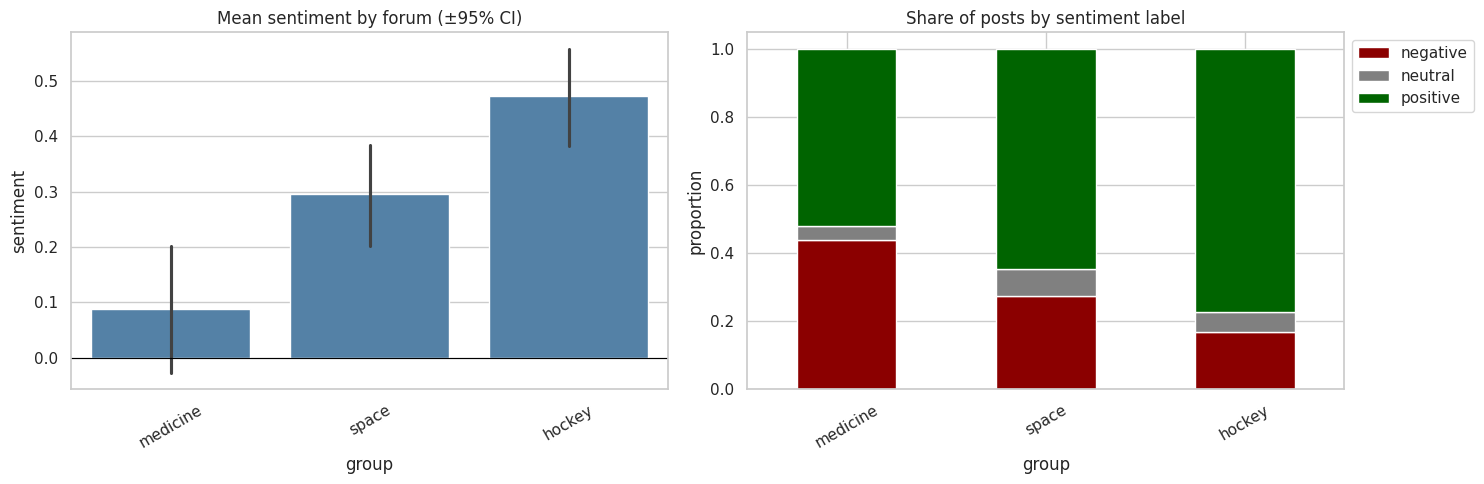

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df, x="group", y="sentiment", order=order, errorbar=("ci", 95),
            ax=axes[0], color="steelblue")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Mean sentiment by forum (±95% CI)")
axes[0].tick_params(axis="x", rotation=30)

props = pd.crosstab(df["group"], df["sentiment_label"], normalize="index").loc[order]
props[["negative", "neutral", "positive"]].plot(kind="bar", stacked=True, ax=axes[1],
                                                color=["darkred", "gray", "darkgreen"])
axes[1].set_title("Share of posts by sentiment label"); axes[1].set_ylabel("proportion")
axes[1].tick_params(axis="x", rotation=30); axes[1].legend(bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

**Discussion:** Is the *medicine* forum more negative because people are more upset, or because the lexicon contains words like *pain*, *cancer*, *death*, and *illness* that are simply part of the topic?

Lexicon-based sentiment partly measures **topic vocabulary**, not only **attitude**. Use `explain_sentiment()` on a few posts to check.

In [73]:
#@title Inspect why a specific post got its score
forum = "medicine" #@param ["space", "medicine", "hockey"]
post_number = 3 #@param {type:"integer"}

def explain_sentiment(text):
    hits = [(w, sia.lexicon[w]) for w in word_tokenize(text.lower()) if w in sia.lexicon]
    print("Scores:", sia.polarity_scores(text))
    print("Lexicon words found:", hits if hits else "none")

forum_posts = df[df["group"] == forum].reset_index(drop=True)

if post_number < 0 or post_number >= len(forum_posts):
    print(f"'{forum}' has {len(forum_posts)} posts. Choose a number from 0 to {len(forum_posts) - 1}.")
else:
    text = forum_posts.loc[post_number, "text"]
    print(f"[{forum}] post {post_number} of {len(forum_posts) - 1}")
    print(textwrap.fill(text[:600], 100), "...\n")
    explain_sentiment(text)

[medicine] post 3 of 149
Also remember that most people map the sanguine/choleric/melencholic/phlegmatic division onto the
extraversion and neuroticism dimensions (Like Eysenck) and that the MBTI does not deal with
neuroticism (Costa & McCrae). ...

Scores: {'neg': 0.128, 'neu': 0.872, 'pos': 0.0, 'compound': -0.4215}
Lexicon words found: [('neuroticism', -0.9), ('like', 1.5), ('neuroticism', -0.9)]


Finally, the UMAP map from Part 2, recolored by sentiment (red = negative, blue = positive):

In [71]:
fig = px.scatter(df, x="x", y="y", color="sentiment", color_continuous_scale="RdBu", range_color=[-1, 1],
                 hover_data={"group": True, "preview": True, "x": False, "y": False},
                 title="Posts by meaning, colored by sentiment", height=600)
fig.update_traces(marker=dict(size=6))
fig.update_xaxes(showticklabels=False, title=""); fig.update_yaxes(showticklabels=False, title="")
fig.show()

---
# Part 4: Topic Modeling

**Topic modeling** tries to discover, without being told, what groups of documents are about. There are two main families:

- **Classic (LDA):** treats each document as a bag of word counts and finds sets of words that tend to co-occur.
- **Embedding-based (e.g., BERTopic):** groups documents that are close in *meaning*, then describes each group by its most distinctive words.

We build the embedding-based version **by hand in four steps**, reusing what we already made:

1. **Embeddings** of each post (done in Part 2)
2. **Reduce** them with UMAP, so clustering works better
3. **Cluster** similar posts together
4. **Describe** each cluster with its most distinctive words (using the cleaned text from Part 1)

## Step 1-2: Reduce the embeddings
Clustering algorithms struggle in 384 dimensions, so we compress to 5. (The 2D version from Part 2 is only for drawing; 5 dimensions keep more information.)

In [74]:
umap_5d = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0, metric="cosine", random_state=42)
reduced = umap_5d.fit_transform(embeddings)
print("Reduced shape:", reduced.shape)

Reduced shape: (450, 5)


## Step 3: Cluster the posts into topics

We use **k-means**, which splits the data into exactly *k* groups. You choose *k*, the number of topics, with the slider. We know there are 6 forums, but try other values (e.g., 4 or 10) and re-run this cell **and all the cells below it** to see how the topics merge or split.

In [78]:
#@title Choose the number of topics
n_topics = 6 #@param {type:"slider", min:2, max:12, step:1}

kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
df["topic"] = kmeans.fit_predict(reduced)
df["topic"].value_counts().sort_index().rename("posts per topic")

,posts per topic
topic,
0,67
1,59
2,71
3,73
4,80
5,100


## Step 4: Describe each topic with its distinctive words

A cluster is just a group of post numbers. To see what it is about and label it for conceptualization, we need words. Simply counting the most common words is not enough: some words might be frequent everywhere. We want words that are **frequent in this topic but rare in the others**.

The method is called **class-based TF-IDF**:
- **TF** (term frequency): how often a word appears within one topic
- **IDF** (inverse document frequency): a bonus for words that are rare across all topics

Here we use the **cleaned** tokens from Part 1, because for describing *what* a topic is about, stopwords would only get in the way.

In [79]:
#@title Find the top words for each topic
# 1. Glue together all the cleaned posts in each topic into one big "topic document"
topic_docs = df.groupby("topic")["clean_text"].apply(" ".join)

# 2. Count words (only words that appear in at least 5 posts, to skip typos)
vectorizer = CountVectorizer(min_df=5).fit(df["clean_text"])
counts = vectorizer.transform(topic_docs).toarray()
vocab = vectorizer.get_feature_names_out()

# 3. TF: each word's share of its topic's words
tf = counts / counts.sum(axis=1, keepdims=True)
# 4. IDF: words spread across every topic get a smaller bonus
avg_words_per_topic = counts.sum() / counts.shape[0]
idf = np.log(1 + avg_words_per_topic / counts.sum(axis=0))
ctfidf = tf * idf

# 5. The top 10 words per topic
top_words = {t: [vocab[i] for i in ctfidf[row].argsort()[::-1][:10]]
             for row, t in enumerate(topic_docs.index)}
topic_names = {t: f"T{t}: " + ", ".join(w[:4]) for t, w in top_words.items()}
df["topic_label"] = df["topic"].map(topic_names)

pd.DataFrame({"topic": list(top_words),
              "posts": df["topic"].value_counts().sort_index().values,
              "top words": [", ".join(w) for w in top_words.values()]})

,topic,posts,top words
0,0,67,"team, game, win, goal, point, play, detroit, year, det, season"
1,1,59,"program, space, system, list, research, object, orbit, nasa, image, data"
2,2,71,"food, msg, people, cause, reaction, time, study, diet, work, pain"
3,3,73,"doctor, science, treatment, pain, patient, medical, medicine, methodology, arm, scientific"
4,4,80,"hockey, team, player, game, nhl, league, arena, city, coach, european"
5,5,100,"space, software, cost, nasa, project, rocket, lunar, year, spacecraft, solar"


The same thing as bar charts (longer bar = more distinctive of that topic):

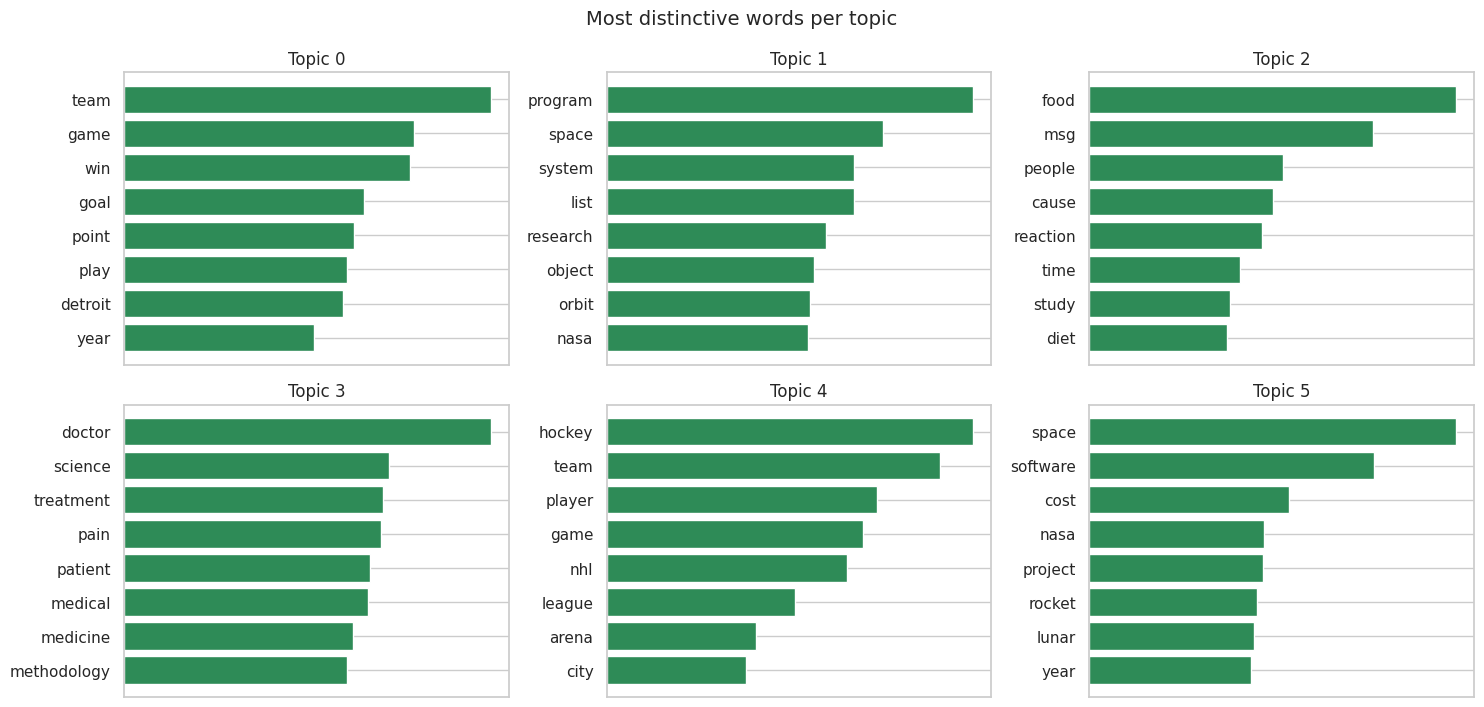

In [80]:
ncols = 3
nrows = int(np.ceil(n_topics / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows))
for ax in np.atleast_1d(axes).flat:
    ax.axis("off")
for row, (ax, t) in enumerate(zip(np.atleast_1d(axes).flat, topic_docs.index)):
    ax.axis("on")
    idx = ctfidf[row].argsort()[::-1][:8]
    ax.barh([vocab[i] for i in idx][::-1], ctfidf[row][idx][::-1], color="seagreen")
    ax.set_title(f"Topic {t}"); ax.set_xticks([])
plt.suptitle("Most distinctive words per topic", fontsize=14)
plt.tight_layout(); plt.show()

Read some posts from one topic to judge whether the label makes sense:

In [84]:
#@title Read posts from a topic
topic_to_read = 0 #@param {type:"integer"}
print(topic_names.get(topic_to_read, "No such topic"), "\n")
for text in df[df["topic"] == topic_to_read]["text"].sample(3, random_state=1):
    print(textwrap.fill(text[:400], 100), "...\n" + "-" * 60)

T0: team, game, win, goal 

3rd uptade: Here are the standings for the poll after 39 votes: 5 points for 1st, 4 for 2nd,... 1
point for 5th: EA/ NHLPA game 1. DET 102 2. CHI 97 3. NY 74 4. VAN 73 5. MTL 69 6. PIT 33 7. WSH 29
8. BOS 21 9..ASW 16 10.CGY 10 11.QUE 9 12.ASE 8 13.WPG 7 14.LA 5 OTW 5 STL 5 TOR 5 18.BUF 3 PHI 3
TBY 3 21.SJ 2 22.MIN 1 Atlanta to win Turner Cup 1 (not in the game, but 1 person vote) 24.EDM 0 HTF
0 L ...
------------------------------------------------------------
Mr. Bettman The Guy in the Wrong Sport Mr. Stein The Guy Who Should Be In Charge But Isn't Of
course, we also need new names for the individual awards, and other stuff like the President's Cup.
President's Cup The Trophy Given To the Best Regular-Season Team Hart winner The Most Valuable
Player, chosen from the Guys in the Middle, the Guys on the Right, the Guys on the Left, the Guys
Back There, a ...
------------------------------------------------------------
I've heard that you can score on Belfour

## 4.1 Visualize topics on the UMAP map

The same 2D map as Part 2, now colored by the discovered **topic** rather than the true forum. Hover to read posts.

In [85]:
fig = px.scatter(df.sort_values("topic"), x="x", y="y", color="topic_label",
                 hover_data={"group": True, "preview": True, "x": False, "y": False},
                 title="Posts colored by discovered topic (UMAP)", height=600)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_xaxes(showticklabels=False, title=""); fig.update_yaxes(showticklabels=False, title="")
fig.update_layout(legend_title_text="topic")
fig.show()

### Did the model rediscover the forums?

Rows are discovered topics; columns are the real forums. Each number counts posts. If each row has one big number, the unsupervised topics line up with the human-defined forums. Posts that land in the "wrong" topic are often the most interesting ones to read.

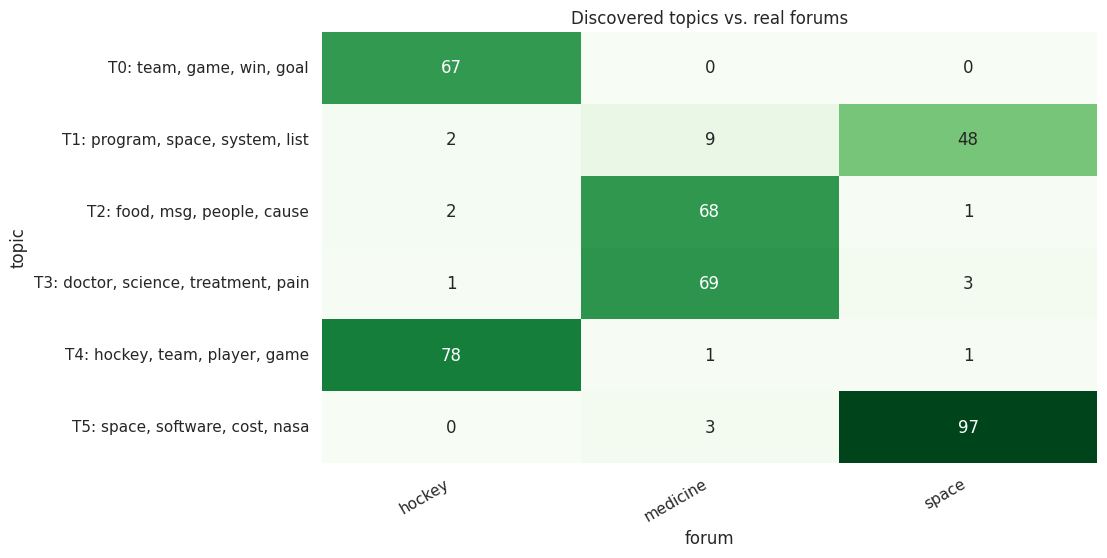

In [86]:
table = pd.crosstab(df["topic_label"], df["group"])
plt.figure(figsize=(10, 0.6 * n_topics + 2))
sns.heatmap(table, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Discovered topics vs. real forums"); plt.xlabel("forum"); plt.ylabel("topic")
plt.xticks(rotation=30, ha="right"); plt.show()

## 4.2 Topic vs. sentiment

Now we combine Parts 3 and 4: which discovered topics are written in a more positive or negative tone?

In [87]:
t_order = df.groupby("topic_label")["sentiment"].median().sort_values().index.tolist()

fig = px.box(df, x="topic_label", y="sentiment", color="topic_label", points="all",
             category_orders={"topic_label": t_order}, hover_data={"group": True, "preview": True},
             title="Sentiment by discovered topic (sorted by median)", height=600)
fig.update_layout(showlegend=False, xaxis_title="topic")
fig.show()

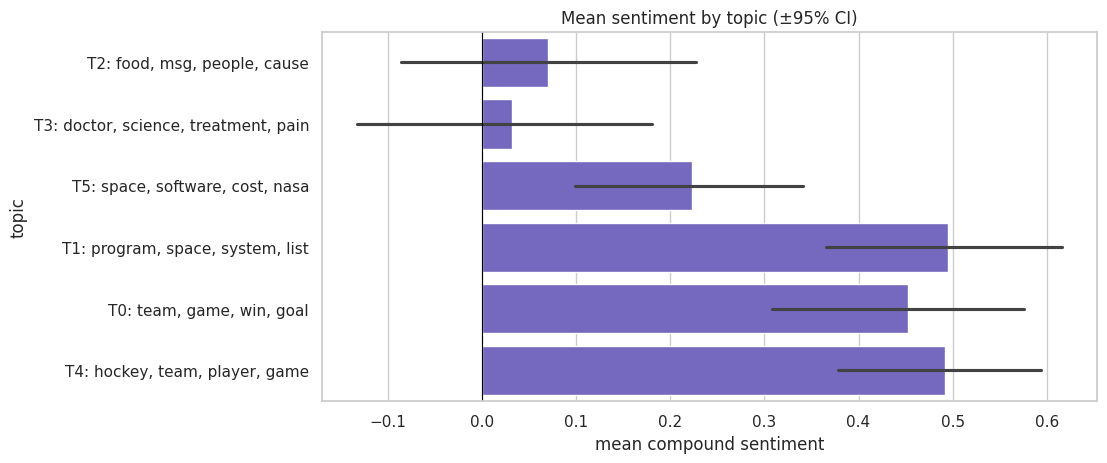

In [89]:
plt.figure(figsize=(10, 0.55 * n_topics + 1.5))
sns.barplot(data=df, y="topic_label", x="sentiment", order=t_order, errorbar=("ci", 95), color="slateblue")
plt.axvline(0, color="black", lw=0.8)
plt.title("Mean sentiment by topic (±95% CI)"); plt.ylabel("topic"); plt.xlabel("mean compound sentiment")
plt.show()

**Discussion questions**
- Do the topic-level sentiment differences look like the forum-level ones from Part 3? Why might they differ?
- Change the number of topics to 10 or 12. Do new sub-topics appear (e.g., a split between hockey *game recaps* and hockey *player trades*)? Do sub-topics within the same forum differ in sentiment?
- Is a "negative" topic really expressing negative attitudes, or just talking about negative *things* (illness, crime, death)? How could you test that?

---
# Recap

| Step | Input | Why |
|---|---|---|
| Word frequencies | cleaned tokens | we want content words, not function words |
| Embeddings / similarity | raw text | the model uses word order, function words, and negation |
| Sentiment (VADER) | raw text | negation, intensifiers, capitals, and punctuation carry sentiment |
| Topic clustering | embeddings of raw text | grouping by meaning |
| Topic labels (top words) | cleaned tokens | describing topics with content words |

### Glossary
- **Token**: one unit (usually a word or punctuation mark) after splitting text.
- **Stopword**: a very frequent function word removed before counting.
- **Lemma**: the dictionary form of a word (*geese → goose*).
- **Embedding**: a list of numbers representing the meaning of a word or text.
- **Cosine similarity**: a measure of how similar two embeddings are (≈0 unrelated, 1 identical).
- **UMAP / PCA**: methods for compressing many dimensions into a few so we can plot or cluster.
- **Lexicon-based sentiment**: scoring text by looking up words in a human-rated dictionary.
- **Clustering (k-means)**: automatically grouping similar items into *k* groups.
- **c-TF-IDF**: a score for how distinctive a word is for one group compared with the others.

### Going further
- **BERTopic** packages Part 4 into a single library, with automatic choice of the number of topics.
- **LDA** (e.g., via `gensim`) is the classic bag-of-words topic model.
- **spaCy** gives part-of-speech tagging, dependency parsing, and POS-aware lemmatization.
- **Transformer sentiment models** (e.g., `cardiffnlp/twitter-roberta-base-sentiment-latest` on Hugging Face) handle context better than a lexicon, but are less transparent.
- **LIWC** is a widely used commercial dictionary-based tool for psychological categories in text.

---
# Appendix: Use your own data

You can run this whole notebook on your own texts. You need a **CSV file** with one column of text and one column of some grouping variable (speaker, genre, year, condition, etc.).

1. Run Part 0 (setup).
2. Run the cell below and upload your file. Type your column names in the boxes first.
3. **Skip cell 1.1** (the 20 Newsgroups loader) and run everything from **1.2** onward.

Some forum-specific form options (like the forum dropdown) will not apply to your data; just skip them. For speed, the cell keeps at most 2,000 rows.

In [ ]:
#@title Upload your own CSV (optional)
text_column  = "text"  #@param {type:"string"}
group_column = "group" #@param {type:"string"}

from google.colab import files
uploaded = files.upload()
my_df = pd.read_csv(list(uploaded.keys())[0])

df = (my_df[[text_column, group_column]]
      .rename(columns={text_column: "text", group_column: "group"})
      .dropna())
df["text"]  = df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["group"] = df["group"].astype(str)
if len(df) > 2000:
    df = df.sample(2000, random_state=42)
df = df.reset_index(drop=True)
print(f"Loaded {len(df)} rows. Now continue from section 1.2.")